# Radio Synchrotron Modelling Analysis

This is a separate notebook just so I don't have to keep rerunning the chains when they look fine

In [48]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.cosmology import Planck18 as cosmo

from corner import corner

import syncfit

from otter import Otter

private_data_path = "private_otter_data"
db = Otter(
    url="http://localhost:8529",
    username="root",
    password="",
    datadir=private_data_path,
    gen_summary=True
)

0.0419

In [16]:
def get_bounds(chain, ndim=3):
    
    medians, upper, lower = [], [], []
    for i in range(ndim):
        mcmc = np.percentile(chain[:, i], [16, 50, 84])
        q = np.diff(mcmc)
        vals = [mcmc[1],(q[0]+q[1])/2]

        medians.append(mcmc[1])
        upper.append(q[1])
        lower.append(q[0])

    return medians, upper, lower


In [29]:
labels = ["p", 'log_F_nu', 'log_nu_a']

best_fit_params = dict(
    name = [],
    mjd = [],
    p = [],
    p_up = [],
    p_lo = [],
    log_F_nu = [],
    log_F_nu_up = [],
    log_F_nu_lo = [],
    log_nu_a = [],
    log_nu_a_up = [],
    log_nu_a_lo = []
)

for jfile in glob.glob(os.path.join(os.getcwd(), "*chains.json")):

    with open(jfile, "r") as j:
        chain_dict = json.load(j)
    
    tname = jfile.split('-')[1].split('/')[1]

    print(tname)

    for k, chain in chain_dict.items():
        medians, uplims, lowlims = get_bounds(np.array(chain))
        print(f"\tMJD = {k}")
        for median, uplim, lowlim, lab in zip(medians, uplims, lowlims, labels):
            print(f"\t\t${lab} = {median:.2f}^+{uplim:.2f}_-{lowlim:.2f}$")

            best_fit_params[lab].append(median)
            best_fit_params[f"{lab}_up"].append(uplim)
            best_fit_params[f"{lab}_lo"].append(lowlim)
        best_fit_params["mjd"].append(k)
        best_fit_params["name"].append(tname)
        
        
    
    print()

res = pd.DataFrame(best_fit_params)

SDSSJ1241
	MJD = 57629.5
		$p = 3.57^+0.21_-0.35$
		$log_F_nu = 1.35^+0.45_-0.37$
		$log_nu_a = 8.74^+0.37_-0.38$
	MJD = 57959.0
		$p = 3.88^+0.09_-0.52$
		$log_F_nu = 1.18^+0.03_-0.04$
		$log_nu_a = 8.98^+0.02_-0.14$
	MJD = 58754.0
		$p = 3.96^+0.03_-0.64$
		$log_F_nu = 0.91^+0.02_-0.03$
		$log_nu_a = 9.01^+0.01_-0.19$
	MJD = 59050.0
		$p = 2.29^+0.23_-0.13$
		$log_F_nu = 1.24^+0.51_-0.56$
		$log_nu_a = 7.58^+0.90_-0.84$
	MJD = 59500.0
		$p = 3.65^+0.26_-0.58$
		$log_F_nu = 1.40^+0.43_-0.60$
		$log_nu_a = 8.44^+0.42_-0.34$

SDSSJ0938
	MJD = 57459.0
		$p = 3.19^+0.37_-0.40$
		$log_F_nu = 1.12^+0.61_-0.46$
		$log_nu_a = 8.65^+0.56_-0.61$
	MJD = 57912.0
		$p = 3.09^+0.16_-0.14$
		$log_F_nu = 1.20^+0.53_-0.24$
		$log_nu_a = 8.44^+0.33_-0.57$

SDSSJ0748
	MJD = 57458.0
		$p = 2.81^+0.63_-0.48$
		$log_F_nu = 0.50^+0.97_-0.84$
		$log_nu_a = 8.15^+1.04_-1.16$
	MJD = 57914.0
		$p = 2.60^+0.45_-0.29$
		$log_F_nu = 0.38^+0.92_-0.73$
		$log_nu_a = 7.73^+1.04_-1.12$



In [50]:
# add in other information we need about each object

redshift = dict(
    SDSSJ1241 = db.get_meta(names="SDSS_J1241", query_private=True)[0].get_redshift(),
    SDSSJ0938 = db.get_meta(names="SDSS_J0938", query_private=True)[0].get_redshift(),
    SDSSJ0748 = db.get_meta(names="SDSS_J0748", query_private=True)[0].get_redshift()
)

disc_date = redshift = dict(
    SDSSJ1241 = db.get_meta(names="SDSS_J1241", query_private=True)[0].get_discovery_date().mjd,
    SDSSJ0938 = db.get_meta(names="SDSS_J0938", query_private=True)[0].get_discovery_date().mjd,
    SDSSJ0748 = db.get_meta(names="SDSS_J0748", query_private=True)[0].get_discovery_date().mjd
)

lum_dist = dict(
    SDSSJ1241 = None,
    SDSSJ0938 = None,
    SDSSJ0748 = None
)

for name, z in redshift.items():
    lum_dist[name] = cosmo.luminosity_distance(z).to("cm").value

res['z'] = res.name.map(redshift)
res["lum_dist"] = res.name.map(lum_dist)
res["disc_date"] = res.name.map(disc_date)

res["dt"] = res.mjd.astype(float) - res.disc_date

res

/home/noahf/astro-otter/otter/src/otter/io/transient.py:880: UserWarning: Names have the same score! Just using the existing default_name
  warnings.warn(
/home/noahf/astro-otter/otter/src/otter/io/transient.py:880: UserWarning: Names have the same score! Just using the existing default_name
  warnings.warn(


,name,mjd,p,p_up,p_lo,log_F_nu,log_F_nu_up,log_F_nu_lo,log_nu_a,log_nu_a_up,log_nu_a_lo,z,lum_dist,disc_date,dt
0,SDSSJ1241,57629.5,3.571883,0.207684,0.352500,1.348285,0.445148,0.365717,8.743547,0.368730,0.384122,53062.0,2.317930e+33,53062.0,4567.5
1,SDSSJ1241,57959.0,3.884762,0.087517,0.516807,1.176276,0.027493,0.037829,8.981878,0.020644,0.144287,53062.0,2.317930e+33,53062.0,4897.0
2,SDSSJ1241,58754.0,3.962760,0.032184,0.638261,0.906718,0.023966,0.033516,9.014308,0.013530,0.188532,53062.0,2.317930e+33,53062.0,5692.0
3,SDSSJ1241,59050.0,2.286125,0.227027,0.131538,1.236303,0.508405,0.563423,7.576586,0.902605,0.836733,53062.0,2.317930e+33,53062.0,5988.0
4,SDSSJ1241,59500.0,3.646321,0.263945,0.577098,1.400793,0.433374,0.601798,8.437228,0.420560,0.343002,53062.0,2.317930e+33,53062.0,6438.0
5,SDSSJ0938,57459.0,3.194251,0.371804,0.404643,1.121971,0.605158,0.455933,8.652002,0.557054,0.610101,54092.0,2.362950e+33,54092.0,3367.0
6,SDSSJ0938,57912.0,3.086663,0.157781,0.135965,1.198764,0.534909,0.238301,8.436692,0.328855,0.571719,54092.0,2.362950e+33,54092.0,3820.0
7,SDSSJ0748,57458.0,2.805552,0.631945,0.479167,0.496527,0.965694,0.839391,8.147339,1.037700,1.156877,52935.0,2.312379e+33,52935.0,4523.0
8,SDSSJ0748,57914.0,2.600990,0.445123,0.286097,0.378762,0.921655,0.731863,7.727498,1.040126,1.119539,52935.0,2.312379e+33,52935.0,4979.0


In [53]:
# do the actual equipartition analysis

res["Req"] = syncfit.analysis.Req(10**res.log_F_nu, res.lum_dist, 10**res.log_nu_a, 10**res.log_nu_a, res.z, res.dt)
res["Gamma"] = syncfit.analysis.lagrange_factor(10**res.log_F_nu, res.lum_dist, 10**res.log_nu_a, 10**res.log_nu_a, res.z, res.dt)
res["Eeq"] = syncfit.analysis.Eeq(10**res.log_F_nu, res.lum_dist, 10**res.log_nu_a, 10**res.log_nu_a, res.z, res.dt)

res

,name,mjd,p,p_up,p_lo,log_F_nu,log_F_nu_up,log_F_nu_lo,log_nu_a,log_nu_a_up,log_nu_a_lo,z,lum_dist,disc_date,dt,Eeq,Req,Gamma
0,SDSSJ1241,57629.5,3.571883,0.207684,0.352500,1.348285,0.445148,0.365717,8.743547,0.368730,0.384122,53062.0,2.317930e+33,53062.0,4567.5,6.215737e+51,2.031612e+18,67.317444
1,SDSSJ1241,57959.0,3.884762,0.087517,0.516807,1.176276,0.027493,0.037829,8.981878,0.020644,0.144287,53062.0,2.317930e+33,53062.0,4897.0,5.388320e+51,6.965109e+17,38.066717
2,SDSSJ1241,58754.0,3.962760,0.032184,0.638261,0.906718,0.023966,0.033516,9.014308,0.013530,0.188532,53062.0,2.317930e+33,53062.0,5692.0,4.219198e+51,3.890968e+17,26.390213
3,SDSSJ1241,59050.0,2.286125,0.227027,0.131538,1.236303,0.508405,0.563423,7.576586,0.902605,0.836733,53062.0,2.317930e+33,53062.0,5988.0,5.610416e+51,6.876701e+19,342.054796
4,SDSSJ1241,59500.0,3.646321,0.263945,0.577098,1.400793,0.433374,0.601798,8.437228,0.420560,0.343002,53062.0,2.317930e+33,53062.0,6438.0,9.214393e+51,5.184228e+18,90.575990
5,SDSSJ0938,57459.0,3.194251,0.371804,0.404643,1.121971,0.605158,0.455933,8.652002,0.557054,0.610101,54092.0,2.362950e+33,54092.0,3367.0,3.081340e+51,2.183021e+18,82.059441
6,SDSSJ0938,57912.0,3.086663,0.157781,0.135965,1.198764,0.534909,0.238301,8.436692,0.328855,0.571719,54092.0,2.362950e+33,54092.0,3820.0,3.814005e+51,4.703653e+18,113.085552
7,SDSSJ0748,57458.0,2.805552,0.631945,0.479167,0.496527,0.965694,0.839391,8.147339,1.037700,1.156877,52935.0,2.312379e+33,52935.0,4523.0,1.484945e+51,3.861431e+18,93.150894
8,SDSSJ0748,57914.0,2.600990,0.445123,0.286097,0.378762,0.921655,0.731863,7.727498,1.040126,1.119539,52935.0,2.312379e+33,52935.0,4979.0,1.268835e+51,1.217955e+19,157.677883


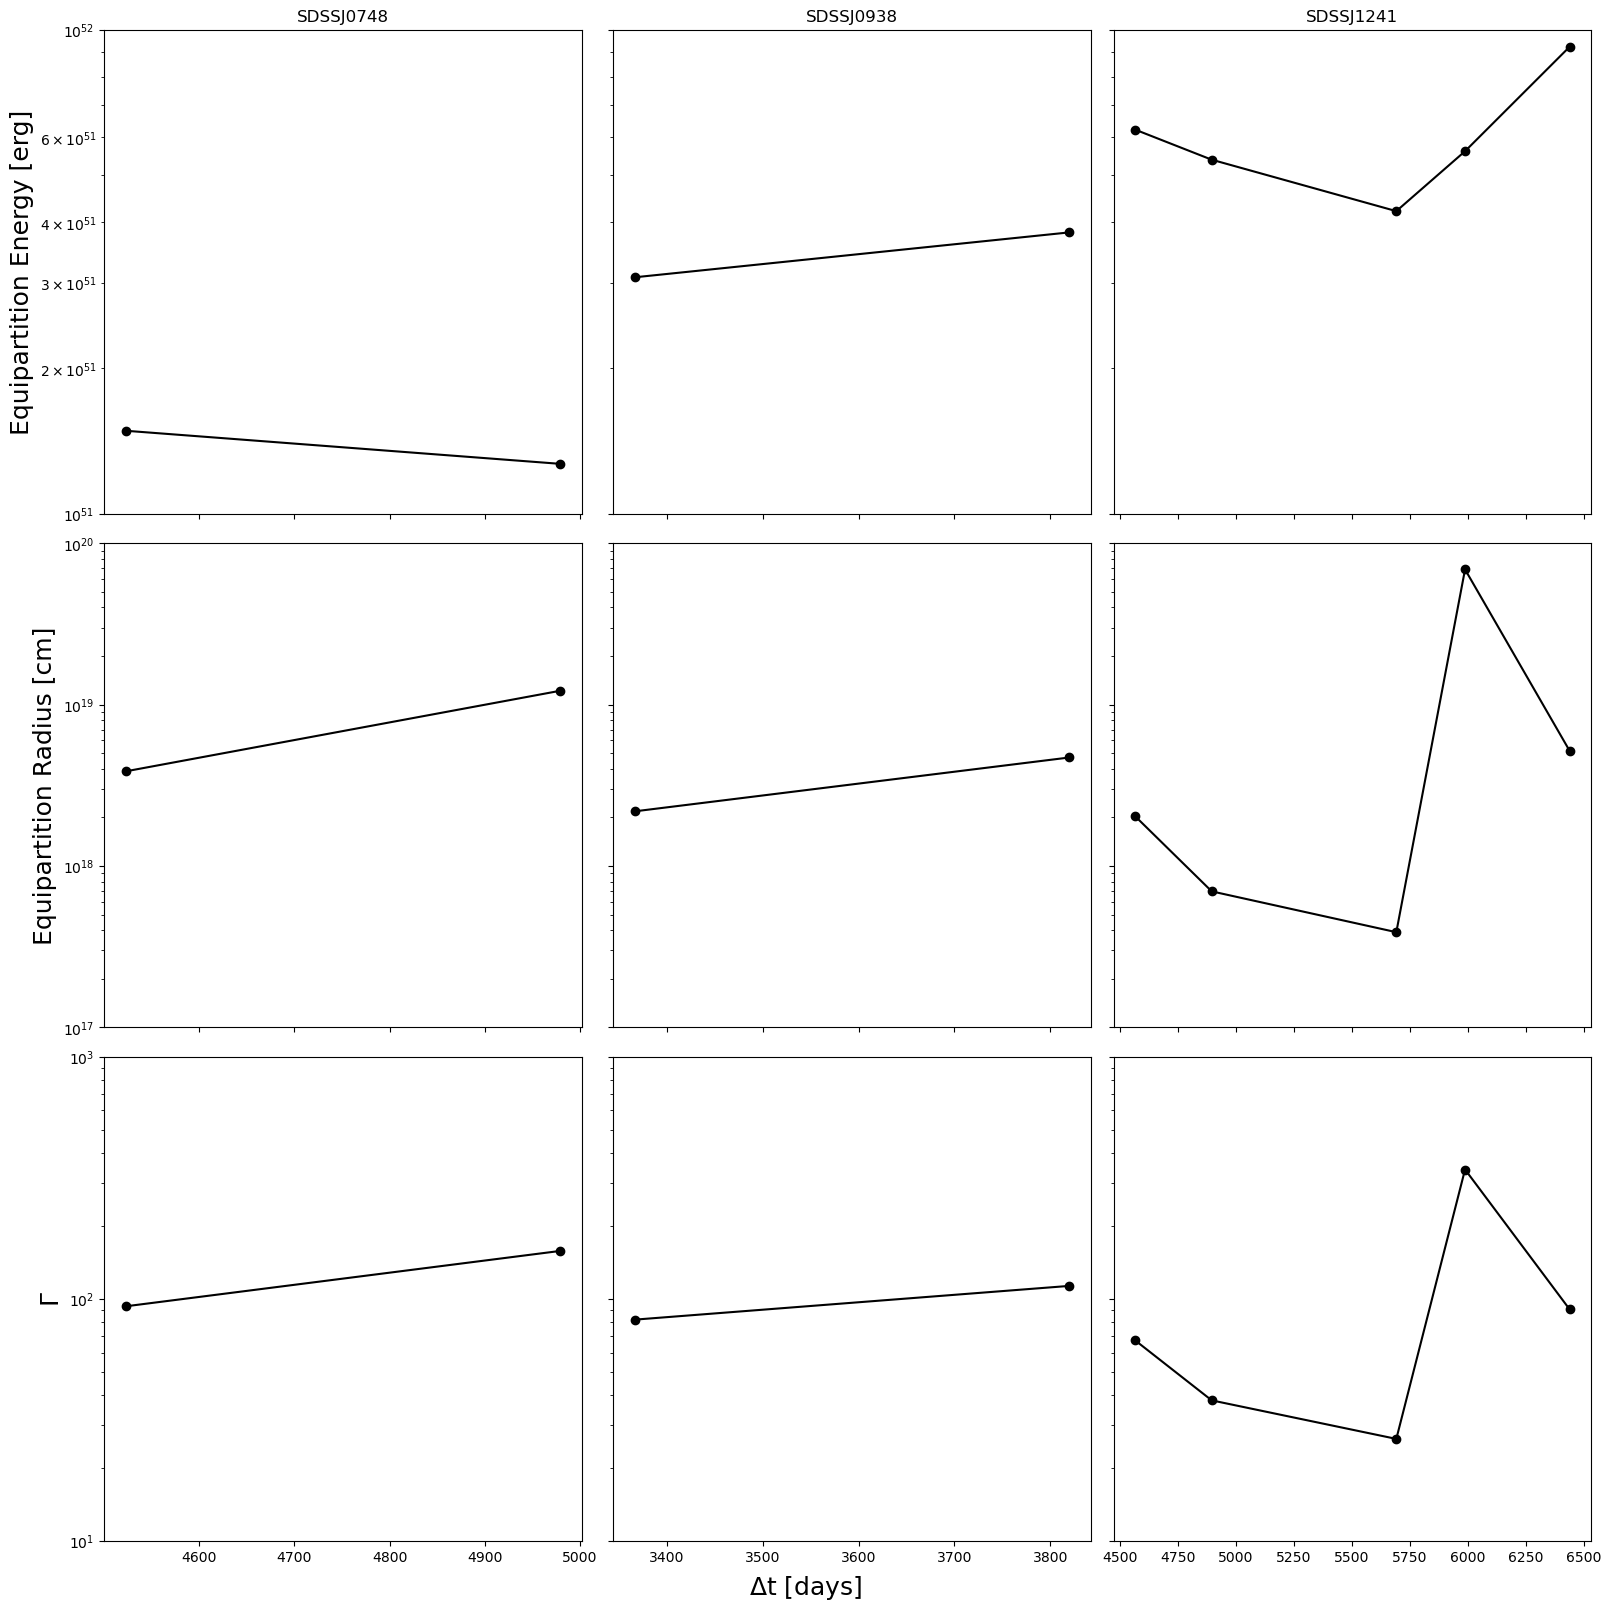

In [78]:
fig, axs = plt.subplots(3,3, sharex="col", sharey="row", figsize=(16,16), layout="constrained")

keys = {
    "Eeq" : "Equipartition Energy [erg]",
    "Req" : "Equipartition Radius [cm]",
    "Gamma" : r"$\Gamma$"
}

ranges = {
    "Eeq" : (1e51, 1e52),
    "Req" : (1e17, 1e20),
    "Gamma" : (1e1, 1e3)    
}

xvar = "dt"

label_fs = 18

for ii, (ax1d, (key, label)) in enumerate(zip(axs, keys.items())):
    ax1d[0].set_ylabel(label, fontsize=label_fs)
    for ax, (name, grp) in zip(ax1d, res.groupby("name")):
        ax.plot(grp[xvar], grp[key], marker='o', linestyle='-', color='k')
        if not ii:
            ax.set_title(f"{name}")

        ax.set_ylim(*ranges[key])
        ax.set_yscale("log")
        # ax.set_xscale("log")

fig.supxlabel(r"$\Delta$t [days]", fontsize=label_fs)

fig.savefig("equipartition-results.png")